# Object Detection

## Learning Objectives
* Explore modern approaches to Computer Vision!

## Context

Imagine you have 500 brain scan images. Each scan potentially contains an anomaly you need to detect. Doing this by hand is tedious and prone to error.

Today, we will teach an AI to find these tumours for us. We will use a tool called PaliGemma.

Most traditiona CV models are "specialists" in that they only do one thing (like detect cars). PaliGemma is a "Generalist." It is a Vision-Language Model (VLM). It has two parts:

* The Eyes (*SigLIP*): A vision model that turns images into numbers.

* The Brain (*Gemma*): A language model that reads those numbers and describes them.

You don't need to train it from scratch. It already knows what "objects" are. We just need to teach it which objects we care about.

### The Setup

First, we need to install the libraries. We are using Keras 3, which is a high-level interface that works with JAX, Google's high-performance numerical computing library (think of JAX as "NumPy for Science").

In [ ]:
# !pip install -U keras_hub # For GPU support
!pip install -U pip -q
!pip install -U "jax[tpu]"==0.6.2 keras-hub==0.21.1 -q # For TPU support

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 47.4 MB/s eta 0:00:00


In [ ]:
# System and data manipulation libraries
import os
import io
import re
import numpy as np

# os.environ["KERAS_BACKEND"] = "jax"
# os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "1.00" # For TPU support

# Deep Learning!
import keras
import keras_hub

#For data vis and reading images
import matplotlib.pyplot as plt
from PIL import Image
import PIL
import requests
from io import BytesIO
import matplotlib.patches as patches

In [ ]:
import kagglehub
kagglehub.login()

In [ ]:
model = keras_hub.models.PaliGemmaCausalLM.from_preset("pali_gemma_3b_mix_224")

print("Model downloaded:",model)

100%|██████████| 1.07k/1.07k [00:00<00:00, 2.04MB/s]


100%|██████████| 4.44k/4.44k [00:00<00:00, 7.80MB/s]


100%|██████████| 4.07M/4.07M [00:00<00:00, 8.61MB/s]

In [ ]:
# These functions are just for reading images and plotting them nicely!
def crop_and_resize(image, target_size):
    width, height = image.size
    source_size = min(image.size)
    left = width // 2 - source_size // 2
    top = height // 2 - source_size // 2
    right, bottom = left + source_size, top + source_size
    return image.resize(target_size, box=(left, top, right, bottom))

def read_local_image(filename, target_size):
    image = PIL.Image.open(filename)
    image = crop_and_resize(image, target_size)
    image = np.array(image)
    # Remove alpha channel if necessary.
    if image.shape[2] == 4:
        image = image[:, :, :3]
    return image

def read_image(url, target_size):
    contents = io.BytesIO(requests.get(url).content)
    image = PIL.Image.open(contents)
    image = crop_and_resize(image, target_size)
    image = np.array(image)
    # Remove alpha channel if necessary.
    if image.shape[2] == 4:
        image = image[:, :, :3]
    return image

def parse_bbox_and_labels(detokenized_output: str):
  matches = re.finditer(
      '<loc(?P<y0>\d\d\d\d)><loc(?P<x0>\d\d\d\d)><loc(?P<y1>\d\d\d\d)><loc(?P<x1>\d\d\d\d)>'
      ' (?P<label>.+?)( ;|$)',
      detokenized_output,
  )
  labels, boxes = [], []
  fmt = lambda x: float(x) / 1024.0
  for m in matches:
    d = m.groupdict()
    boxes.append([fmt(d['y0']), fmt(d['x0']), fmt(d['y1']), fmt(d['x1'])])
    labels.append(d['label'])
  return np.array(boxes), np.array(labels)

def display_boxes(image, boxes, labels, target_image_size):
  h, l = target_size
  fig, ax = plt.subplots()
  ax.imshow(image)
  for i in range(boxes.shape[0]):
      y, x, y2, x2 = (boxes[i]*h)
      width = x2 - x
      height = y2 - y
      # Create a Rectangle patch
      rect = patches.Rectangle((x, y),
                               width,
                               height,
                               linewidth=1,
                               edgecolor='r',
                               facecolor='none')
      # Add label
      plt.text(x, y, labels[i], color='red', fontsize=12)
      # Add the patch to the Axes
      ax.add_patch(rect)

  plt.show()

def display_segment_output(image, bounding_box, segment_mask, target_image_size):
    # Initialize a full mask with the target size
    full_mask = np.zeros(target_image_size, dtype=np.uint8)
    target_width, target_height = target_image_size

    for bbox, mask in zip(bounding_box, segment_mask):
        y1, x1, y2, x2 = bbox
        x1 = int(x1 * target_width)
        y1 = int(y1 * target_height)
        x2 = int(x2 * target_width)
        y2 = int(y2 * target_height)

        # Ensure mask is 2D before converting to Image
        if mask.ndim == 3:
            mask = mask.squeeze(axis=-1)
        mask = Image.fromarray(mask)
        mask = mask.resize((x2 - x1, y2 - y1), resample=Image.NEAREST)
        mask = np.array(mask)
        binary_mask = (mask > 0.5).astype(np.uint8)


        # Place the binary mask onto the full mask
        full_mask[y1:y2, x1:x2] = np.maximum(full_mask[y1:y2, x1:x2], binary_mask)
    cmap = plt.get_cmap('jet')
    colored_mask = cmap(full_mask / 1.0)
    colored_mask = (colored_mask[:, :, :3] * 255).astype(np.uint8)
    if isinstance(image, Image.Image):
        image = np.array(image)
    blended_image = image.copy()
    mask_indices = full_mask > 0
    alpha = 0.5

    for c in range(3):
        blended_image[:, :, c] = np.where(mask_indices,
                                          (1 - alpha) * image[:, :, c] + alpha * colored_mask[:, :, c],
                                          image[:, :, c])

    fig, ax = plt.subplots()
    ax.imshow(blended_image)
    plt.show()

### Read an image
And have a look at it

In [ ]:
target_size = (224, 224)
image_url = 'https://storage.googleapis.com/keras-cv/models/paligemma/cow_beach_1.png'
cow_image = read_image(image_url, target_size)
plt.imshow(cow_image)

Model Output: detect cow
<loc0274><loc0000><loc1022><loc0688> cow


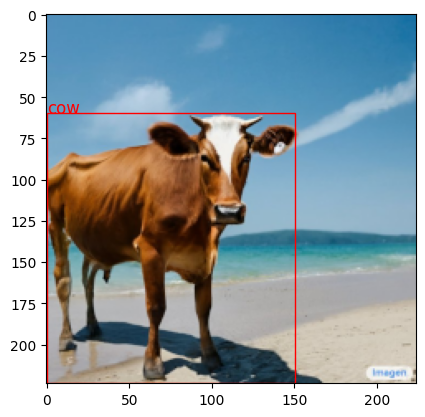

In [ ]:
# Ask the model to find the cow
# Note: The prompt must mimic how the model was trained.
prompt = "detect cow\n"

# Run the model!
output = model.generate({
    "images": cow_image,
    "prompts": prompt
})

print("Model Output:", output)

boxes, labels = parse_bbox_and_labels(output)
display_boxes(cow_image, boxes, labels, target_size)

In [ ]:
# Download a real dataset of tumors in a brain (coco format) https://www.kaggle.com/datasets/pkdarabi/brain-tumor-image-dataset-semantic-segmentation/data
!curl -L -o brain-tumor-image-dataset-semantic-segmentation.zip\
  https://www.kaggle.com/api/v1/datasets/download/pkdarabi/brain-tumor-image-dataset-semantic-segmentation
!unzip -q brain-tumor-image-dataset-semantic-segmentation.zip

# Wrangle the data into the right structure
!mkdir train/images
!mv train/*.jpg train/images

!mkdir valid/images
!mv valid/*.jpg valid/images

!jq '.categories |= map(.id += 1) | .annotations |= map(.category_id += 1)' train/_annotations.coco.json > train/labels.json
!jq '.categories |= map(.id += 1) | .annotations |= map(.category_id += 1)' valid/_annotations.coco.json > valid/labels.json
!ls

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 83.6M  100 83.6M    0     0   111M      0 --:--:-- --:--:-- --:--:--  111M
replace README.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
mkdir: cannot create directory ‘train/images’: File exists
mkdir: cannot create directory ‘valid/images’: File exists
brain-tumor-image-dataset-semantic-segmentation.zip  sample_data  train
README.txt					     test	  valid


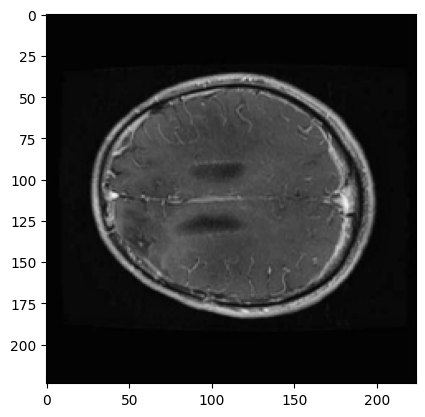

In [ ]:
image_url = '/content/valid/images/1997_jpg.rf.57e306420710246d04c0d5c26e6496c6.jpg'
wbc_image_resized = read_local_image(image_url, target_size)
plt.imshow(wbc_image_resized)

Untrained Output: detect tumor
<loc0161><loc0120><loc0844><loc0914> tumor


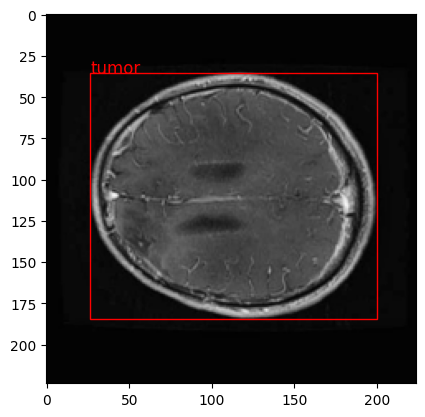

In [ ]:
# Test the model WITHOUT training
prompt = "detect tumor\n"
output = model.generate({
    "images": wbc_image_resized,
    "prompts": prompt
})

print("Untrained Output:", output)
boxes, labels = parse_bbox_and_labels(output)
display_boxes(wbc_image_resized, boxes, labels, target_size)

In [ ]:
# The prompt we will use
training_prompt = "detect brain tumor\n"


# The answer we WANT the model to learn.
# These tokens represent a box around the cancer.
# <locxxxx> manually determined from labeled /content/valid/images/1997_jpg.rf.57e306420710246d04c0d5c26e6496c6.jpg converted from COCO to PALIGemma
training_label = "<loc0181><loc0467><loc0341><loc0693> tumor"

# Combine them into a list
# In Keras, we feed data as a dictionary
training_data = {
    "images": [np.array(wbc_image_resized)],
    "prompts": [training_prompt],
    "responses": [training_label],
}

In [ ]:
# Enable LoRA on the model backbone
# "rank=4" means the adapter is very small and fast to train
model.backbone.enable_lora(rank=4)

# Limit the sequence length to save memory (we only need short answers)
model.preprocessor.sequence_length = 32

# Compile the model (Prepare it for training)
# We use standard Adam optimizer
model.compile(
    # loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.Adam(learning_rate=5e-5),
    weighted_metrics=["accuracy"],
    jit_compile=True
)

print("LoRA enabled. Model is ready to train!")

LoRA enabled. Model is ready to train!


In [ ]:
# Train for 5 epochs (passes over the data)
# Since we only have 1 image, this should be fast
history = model.fit(
    training_data,
    epochs=5,
    batch_size=1
)


Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 67s 67s/step - accuracy: 0.0000e+00 - loss: 1.3628
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 61s 61s/step - accuracy: 0.0000e+00 - loss: 1.3600
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.0000e+00 - loss: 1.3543
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - accuracy: 0.0000e+00 - loss: 1.3489
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.0000e+00 - loss: 1.3412


Running inference on the fine-tuned model...
Raw Output: detect tumor
<loc0163><loc0120><loc0844><loc0914> tumor


TypeError: cannot unpack non-iterable int object

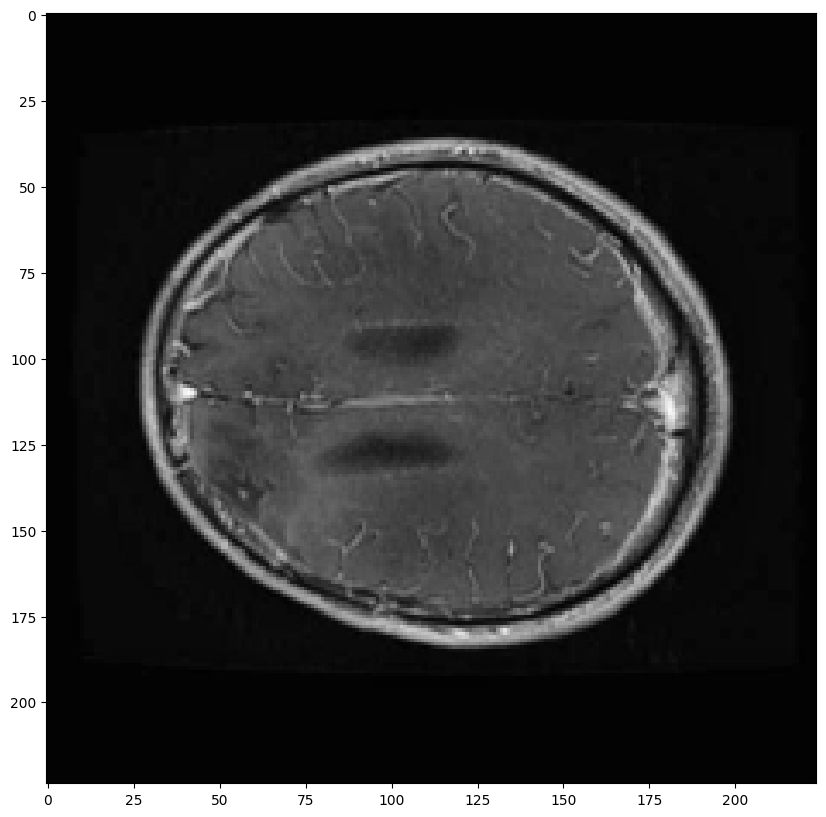

In [ ]:
# Run Inference
print("Running inference on the fine-tuned model...")
result = model.generate({
    "images": wbc_image_resized,
    "prompts": "detect tumor\n"
})

print("Raw Output:", result)
boxes, labels = parse_bbox_and_labels(result)
display_boxes(wbc_image_resized, boxes, labels, target_size)

In [ ]:
image_url_2 = '/content/valid/images/1001_jpg.rf.a64df329f81626672c9b81f95d421c84.jpg'
wbc_image_resized_2 = read_local_image(image_url_2, target_size)

# Run Inference on New images

# Test the model WITHOUT training
prompt = "detect tumor\n"
result = model.generate({
    "images": wbc_image_resized_2,
    "prompts": prompt
})

print("Trained Output:", result)
boxes, labels = parse_bbox_and_labels(result)
display_boxes(wbc_image_resized_2, boxes, labels, target_size)

In [ ]:
prompt = 'segment cow\n'
output = paligemma.generate(
    inputs={
        "images": cow_image,
        "prompts": prompt,
    }
)

bboxes, seg_masks = parse_segments(output)
display_segment_output(cow_image, bboxes, seg_masks, target_size)

In [ ]:
# Helper function to convert between coco and paligemma

def coco_to_paligemaa(coco_bbox, image_width, image_height, scale=1000.0):
    """
    Converts a bounding box from COCO format to PaliGemaa-style normalized coordinates.

    COCO Format: [x_min, y_min, width, height] (Absolute pixel values)
    PaliGemaa Format: [x_min_norm, y_min_norm, x_max_norm, y_max_norm] (Normalized 0.0 to scale)

    Args:
        coco_bbox (list or tuple): A sequence of four floats/ints [x_min, y_min, width, height].
        image_width (int): The width of the image in pixels.
        image_height (int): The height of the image in pixels.
        scale (float): The target maximum value for normalization (e.g., 1000.0 for
                       PaliGemaa or 1.0 for standard normalization).

    Returns:
        list: A list of four floats [x_min_norm, y_min_norm, x_max_norm, y_max_norm].
              Returns None if the image dimensions are invalid (zero or negative).
    """

    x_min_abs, y_min_abs, width_abs, height_abs = coco_bbox

    # 1. Calculate the bottom-right coordinates (x_max, y_max)
    x_max_abs = x_min_abs + width_abs
    y_max_abs = y_min_abs + height_abs

    # 2. Normalize the absolute pixel coordinates (scale to 0.0-1.0)
    x_min_norm_unit = x_min_abs / image_width
    y_min_norm_unit = y_min_abs / image_height
    x_max_norm_unit = x_max_abs / image_width
    y_max_norm_unit = y_max_abs / image_height

    # Ensure coordinates are clamped to the 0.0 to 1.0 range
    x_min_norm_unit = max(0.0, min(1.0, x_min_norm_unit))
    y_min_norm_unit = max(0.0, min(1.0, y_min_norm_unit))
    x_max_norm_unit = max(0.0, min(1.0, x_max_norm_unit))
    y_max_norm_unit = max(0.0, min(1.0, y_max_norm_unit))

    # 3. Scale the coordinates to the target value (e.g., 1000.0)
    x_min_paligemaa = round(x_min_norm_unit * scale, 2)
    y_min_paligemaa = round(y_min_norm_unit * scale, 2)
    x_max_paligemaa = round(x_max_norm_unit * scale, 2)
    y_max_paligemaa = round(y_max_norm_unit * scale, 2)

    return [x_min_paligemaa, y_min_paligemaa, x_max_paligemaa, y_max_paligemaa]

  coco_to_paligemaa([116,300,102.5,143.75],640,640)